# Cross-modal integration: Cell Painting morphology vs. scRNA-seq --- Testing PLS and CCA

Key question : Using known compound pairs as supervision, can PLS or CCA align morphology and RNA profiles such that a held-out morphology profile retrieves its held-out paired RNA profile better than chance?

PLS and CCA and 'cross-decomposition' methods

CCA (Canonical Correlation Analysis) -- Construct linear combinations of X and Y variables with the constraint of maximizing correlation

PLS (canonical) --- Construct linear combinations of X and Y while maximizing covariance (product of correlation x stdev(x) x stdev(y))

Task: 
Performance of the transformation is evaluated in a 80/20 train-test split with 5-fold validation
Construct PLS/CCA on train dataaset (80% of drug RNA-morphology PCA vectors) --> 
Apply model to test dataset, calculate test-compund by test-cmpound distance matrix (For 119x30 RNA and 119x30 Morphology inputs, we will have 239 points in the reduced space (one from morphology and one from RNA))
Evaluate based on 'ranks' : Calulcate distances between 'true' pairs and see how 'close' it is relative to other points (Rank based metric)

Evaluating overall performance relative to a Good negative control (null) is randomly permuting the drug label to break any correlation


In [1]:
import glob
import os
import re
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pycytominer import feature_select, normalize
from pycytominer.cyto_utils import infer_cp_features
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["font.size"] = 10

RANDOM_STATE = 0
N_PCS = 30

PALETTE = [
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
    "#008300", "#4a3aa7", "#e34948", "#6b4226", "#38a5b0",
    "#a24fbf", "#c2914e", "#5a6bd6", "#c65da0", "#6f9e1f",
    "#d65f5f", "#3f7d8c", "#9a7dcb", "#b25b2a", "#4f9d6e",
    "#8c8c8c",
]


## 1. Load gene expression



In [2]:
rna = ad.read_h5ad("./data/hepg2_cells.h5ad")
rna.var_names = rna.var["gene_symbol"].astype(str)
rna.var_names_make_unique()

print(f"{rna.n_obs} cells x {rna.n_vars} genes")
print(f"{rna.obs['drug'].nunique()} drugs, {rna.obs['plate'].nunique()} plates, "
      f"{rna.obs['moa-fine'].nunique()} moa-fine classes, cell line {rna.obs['cell_line_id'].unique().tolist()}")

drug_summary = (
    rna.obs.groupby("drug", observed=True)
    .agg(n_cells=("drug", "size"), moa_fine=("moa-fine", "first"))
    .sort_values("n_cells")
)
drug_summary.head()


389085 cells x 62710 genes
120 drugs, 14 plates, 21 moa-fine classes, cell line ['CVCL_1098']


,n_cells,moa_fine
drug,,
Menadione,925,unclear
Clofarabine,1006,DNA synthesis/repair inhibitor
Pemetrexed,1015,DNA synthesis/repair inhibitor
Canagliflozin,1079,Glucose transporter inhibitor
Silodosin,1110,unclear


## 2. Match compounds between datasets


In [3]:
ANNOTATION_DIR = "../annotations"

compounds = pd.read_csv(os.path.join(ANNOTATION_DIR, "pd_export_04_2022_2464_compounds_standardized.csv"))
compounds = compounds.drop_duplicates(subset="name", keep="first")
name_to_pdid = dict(zip(compounds["name"].str.lower().str.strip(), compounds["pdid"]))

synonym_to_pdid = {}
for _, row in compounds.iterrows():
    for syn in str(row["synonyms"] or "").split(";"):
        syn = syn.strip().lower()
        if syn:
            synonym_to_pdid.setdefault(syn, row["pdid"])

# Common salt/hydrate/counter-ion suffixes that show up as a bare trailing
# word rather than inside parentheses (e.g. "Larotrectinib sulfate",
# "Ralimetinib dimesylate") - stripped repeatedly in case more than one is
# stacked (e.g. "... dihydrochloride hydrate").
SALT_SUFFIX_RE = re.compile(
    r"\s+(?:hydrochlorides?|dihydrochloride|trihydrochloride|sulfates?|disulfate|"
    r"bisulfate|mesylate|dimesylate|tosylate|besylate|maleate|fumarate|"
    r"citrate|acetate|phosphate|diphosphate|hydrobromide|dihydrobromide|"
    r"succinate|oxalate|nitrate|lactate|malate|gluconate|tartrate|bitartrate|"
    r"hemihydrate|monohydrate|dihydrate|trihydrate|tetrahydrate|hydrate|"
    r"sodium|potassium|calcium|iodide|bromide|chloride|palmitate|stearate|"
    r"benzoate|carbonate|bicarbonate|pamoate|isethionate|napadisylate|"
    r"edisylate)\s*$",
    re.IGNORECASE,
)


def strip_formulation_suffix(name: str) -> str:
    name = re.sub(r"\s*\([^)]*\)\s*$", "", name).strip()
    prev = None
    while prev != name:
        prev = name
        name = SALT_SUFFIX_RE.sub("", name).strip()
    return name


def match_drug_to_pdid(drug: str) -> str | None:
    key = drug.lower().strip()
    for candidate in (key, strip_formulation_suffix(key)):
        if candidate in name_to_pdid:
            return name_to_pdid[candidate]
        if candidate in synonym_to_pdid:
            return synonym_to_pdid[candidate]
    return None


drug_to_pdid = {d: match_drug_to_pdid(d) for d in rna.obs["drug"].cat.categories}
n_matched = sum(v is not None for v in drug_to_pdid.values())
print(f"Matched {n_matched}/{len(drug_to_pdid)} drugs to the morphology compound reference")
print("Unmatched:", [d for d, p in drug_to_pdid.items() if p is None])

Matched 120/120 drugs to the morphology compound reference
Unmatched: []


## 3. Gene expression: cell-level PCA, averaged per drug

Standard scanpy pipeline (total-count normalize, log1p, highly-variable
genes, PCA) at single-cell resolution, then average each drug's cells'
PC coordinates into one embedding per drug. Averaging post-PCA (rather than
pseudobulking raw counts pre-PCA) keeps the gene-expression side on the same
"reduce fine-grained observations to one PCA space, then average within
group" logic used for morphology below.


In [18]:
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=2000)
sc.pp.pca(rna, n_comps=N_PCS, mask_var="highly_variable", random_state=RANDOM_STATE)

rna_pcs = pd.DataFrame(rna.obsm["X_pca"], index=rna.obs_names)
rna_pcs["drug"] = rna.obs["drug"].to_numpy()
rna_compound_pca = rna_pcs.groupby("drug", observed=True).mean()

moa_by_drug = rna.obs.groupby("drug", observed=True)["moa-fine"].first()

print(f"Per-drug expression embedding: {rna_compound_pca.shape}")
rna_compound_pca.head()


Per-drug expression embedding: (120, 30)


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
drug,,,,,,,,,,,,,,,,,,,,,
18β-Glycyrrhetinic acid,0.259844,-0.199803,0.207169,0.105615,-0.013520,-0.095739,-0.078868,0.007638,0.028525,0.005639,...,-0.012958,0.071196,0.024508,0.011374,0.006950,0.023077,0.004934,0.036947,-0.054243,0.033440
5-Fluorouracil,-0.251401,0.335395,-0.130008,-0.032769,0.283900,0.116016,0.170694,0.051685,0.055462,0.009434,...,0.058384,0.057779,-0.018176,-0.040850,-0.014730,-0.021529,-0.045237,-0.029298,-0.064453,0.022364
8-Hydroxyquinoline,0.591201,-0.207962,0.103034,0.039423,0.013281,-0.044024,-0.142196,-0.035398,0.114536,0.104523,...,-0.054798,-0.037560,0.057521,0.042116,0.040854,-0.012645,0.016561,0.006820,0.005452,-0.041295
AT7519,0.162207,-0.049629,0.127904,0.142323,0.001974,-0.054525,-0.138121,0.028969,-0.025132,-0.022478,...,-0.027913,-0.009744,0.034883,0.006966,0.042982,-0.009754,0.027700,0.042756,0.021056,0.002589
AZD-8055,0.127986,0.011980,-0.023481,-0.032323,-0.044747,0.018247,-0.193425,-0.076931,-0.091368,-0.162471,...,-0.052097,-0.071604,-0.097621,0.048540,0.013279,-0.076044,0.023884,0.012730,0.045906,0.010012


## 4. Morphology: well-level PCA over pooled HepG2 sites, averaged per compound

Reuses the same loading / per-plate `mad_robustize` normalization / well-
annotation join as `morphology_umap_analysis.ipynb`, restricted to the four
HepG2 production sites (`FMP_U2OS` is excluded - the gene expression data is
HepG2 only). Feature selection is run once on the pooled HepG2 profiles so
all four sites share one feature set, mirroring the "combined" analysis in
the morphology notebook.


In [5]:
DATA_DIR = "../aggregated_data"
HEPG2_SITES = [d for d in sorted(os.listdir(DATA_DIR)) if d.endswith("HepG2")]
COMPARTMENTS = ["Cells", "Nuc", "Cyto"]

PLATE_RE = re.compile(r"B\d{3,}")
REPLICATE_RE = re.compile(r"(?<![A-Za-z])R\d+")


def parse_plate_replicate(filename: str) -> tuple[str, str]:
    return PLATE_RE.search(filename).group(), REPLICATE_RE.search(filename).group()


def load_site_profiles(site_dir: str, site_name: str) -> pd.DataFrame:
    frames = []
    for f in sorted(glob.glob(os.path.join(site_dir, "*.csv"))):
        d = pd.read_csv(f)
        feature_cols = [c for c in d.columns if not c.startswith("Metadata_")]
        d[feature_cols] = d[feature_cols].astype("float32")
        plate, replicate = parse_plate_replicate(os.path.basename(f))
        d["Metadata_Site"] = site_name
        d["Metadata_PlateID"] = plate
        d["Metadata_Replicate"] = replicate
        d["Metadata_SourceFile"] = f"{site_name}_{plate}_{replicate}"
        frames.append(d)
    return pd.concat(frames, ignore_index=True)


def normalize_per_plate(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    parts = [
        normalize(
            group, features=features, meta_features="infer",
            samples="all", method="mad_robustize",
        )
        for _, group in df.groupby("Metadata_SourceFile")
    ]
    return pd.concat(parts, ignore_index=True)


print(f"HepG2 sites: {HEPG2_SITES}")
hepg2_raw = {site: load_site_profiles(os.path.join(DATA_DIR, site), site) for site in HEPG2_SITES}

FEATURES = infer_cp_features(next(iter(hepg2_raw.values())), compartments=COMPARTMENTS)
hepg2_normalized = {site: normalize_per_plate(df, FEATURES) for site, df in hepg2_raw.items()}
hepg2_pooled = pd.concat(hepg2_normalized.values(), ignore_index=True)
print(f"{len(hepg2_pooled)} wells pooled across {len(HEPG2_SITES)} HepG2 sites, {len(FEATURES)} inferred features")


HepG2 sites: ['FMP_HepG2', 'IMTM_HepG2', 'MEDINA_HepG2', 'USC_HepG2']
42847 wells pooled across 4 HepG2 sites, 2977 inferred features


In [6]:
FEATURE_SELECT_OPS = [
    "variance_threshold", "frequency_threshold", "correlation_threshold",
    "drop_na_columns", "blocklist", "drop_outliers",
]
hepg2_selected = feature_select(hepg2_pooled, features=FEATURES, operation=FEATURE_SELECT_OPS)
morph_feature_cols = [c for c in hepg2_selected.columns if not c.startswith("Metadata_")]
print(f"{len(morph_feature_cols)} features selected on pooled HepG2 data")

SITE_ANNOTATION_FILES = {
    "FMP_HepG2": "2022-07-08_Annotation_Bioactives_HepG2.csv",
    "IMTM_HepG2": "2023-08-14_Annotation2_IMTM_HepG2.csv",
    "MEDINA_HepG2": "2023-11-28_Annotation_MEDINA_HepG2.csv",
    "USC_HepG2": "2023-11-28_Annotation_USC_HepG2.csv",
}
eos_to_pdid = pd.read_csv(os.path.join(ANNOTATION_DIR, "2024-08-02_EOS_pdid.csv"))
eos_to_pdid_map = dict(zip(eos_to_pdid["Metadata_EOS"], eos_to_pdid["Metadata_pdid"]))


def load_well_pdid(site: str) -> pd.DataFrame:
    ann = pd.read_csv(os.path.join(ANNOTATION_DIR, SITE_ANNOTATION_FILES[site]))
    ann = ann.rename(columns={"Metadata_Plate": "Metadata_PlateID", "Metadata_Batch": "Metadata_Replicate"})
    ann["Metadata_pdid"] = ann["Metadata_EOS"].map(eos_to_pdid_map)
    ann["Metadata_negcon"] = ann["Metadata_EOS"] == "DMSO"
    return ann[["Metadata_PlateID", "Metadata_Well", "Metadata_Replicate", "Metadata_pdid", "Metadata_negcon"]]


hepg2_selected = pd.concat(
    [
        group.merge(load_well_pdid(site), on=["Metadata_PlateID", "Metadata_Well", "Metadata_Replicate"], how="left")
        for site, group in hepg2_selected.groupby("Metadata_Site")
    ],
    ignore_index=True,
)
print(f"{hepg2_selected['Metadata_pdid'].notna().mean():.1%} of HepG2 wells resolved to a pdid")


636 features selected on pooled HepG2 data
91.6% of HepG2 wells resolved to a pdid


In [7]:
morph_adata = ad.AnnData(
    X=hepg2_selected[morph_feature_cols].to_numpy(dtype=np.float32),
    obs=hepg2_selected[["Metadata_Site", "Metadata_pdid"]].reset_index(drop=True),
)
n_pcs_morph = min(N_PCS, morph_adata.n_vars - 1, morph_adata.n_obs - 1)
sc.pp.pca(morph_adata, n_comps=n_pcs_morph, random_state=RANDOM_STATE)

pdid_to_drug = {pdid: drug for drug, pdid in drug_to_pdid.items() if pdid is not None}

morph_pcs = pd.DataFrame(morph_adata.obsm["X_pca"], index=morph_adata.obs_names)
morph_pcs["drug"] = morph_adata.obs["Metadata_pdid"].map(pdid_to_drug).to_numpy()
morph_compound_pca = morph_pcs.dropna(subset=["drug"]).groupby("drug").mean()

print(f"Per-compound morphology embedding: {morph_compound_pca.shape}")
morph_compound_pca.head()


Per-compound morphology embedding: (119, 30)


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
drug,,,,,,,,,,,,,,,,,,,,,
18β-Glycyrrhetinic acid,-6.399389,-1.832657,-0.997449,0.897172,2.423206,-1.025951,1.728302,-0.065975,0.500277,2.347806,...,-0.137482,0.533174,0.535945,-0.361876,0.242805,-0.645506,-0.571942,0.736578,-0.372313,0.220263
5-Fluorouracil,1.409759,21.360697,10.415136,-7.124658,3.451058,-4.621083,0.976545,3.075159,-4.475659,3.289508,...,0.013137,-1.460834,1.574723,0.868982,4.448579,0.459373,0.732467,-1.817052,-1.957553,3.731517
8-Hydroxyquinoline,-8.338190,2.989311,1.421946,-0.004675,-7.868055,-3.681122,2.450382,3.361848,-7.914018,-0.562289,...,1.162524,-0.001628,1.251604,5.869569,-1.649560,1.629299,-0.599169,-1.435161,1.748693,-0.496995
AT7519,-12.874372,18.154467,-18.858984,23.290222,-24.371866,-11.832573,6.594124,16.880505,2.072487,-3.027154,...,-2.972489,1.245813,-0.208984,0.811829,-3.893679,0.784076,-0.356055,-2.009978,3.856736,0.560605
AZD-8055,10.100132,14.107737,6.865217,-1.750054,11.126133,6.824182,-1.361056,10.689266,-1.385265,3.372160,...,1.564135,4.433916,2.726877,-1.334964,1.383548,1.066030,0.222003,-0.280964,-4.267215,-0.880181


In [19]:
rna_compound_filt_pca = rna_compound_pca[rna_compound_pca.index.isin(morph_compound_pca.index)]

assert morph_compound_pca.index.equals(rna_compound_filt_pca.index)

In [28]:
print(morph_compound_pca.index)
print(rna_compound_filt_pca.index)

Index(['18β-Glycyrrhetinic acid', '5-Fluorouracil', '8-Hydroxyquinoline',
       'AT7519', 'AZD-8055', 'AZD2858', 'Abiraterone acetate', 'Acetohexamide',
       'Aliskiren', 'Alpelisib',
       ...
       'Valdecoxib', 'Vemurafenib', 'Vinblastine (sulfate)', 'Vismodegib',
       'Voriconazole', 'Vortioxetine', 'Zileuton', 'olaparib', 'palbociclib',
       'venetoclax'],
      dtype='str', name='drug', length=119)
Index(['18β-Glycyrrhetinic acid', '5-Fluorouracil', '8-Hydroxyquinoline',
       'AT7519', 'AZD-8055', 'AZD2858', 'Abiraterone acetate', 'Acetohexamide',
       'Aliskiren', 'Alpelisib',
       ...
       'Valdecoxib', 'Vemurafenib', 'Vinblastine (sulfate)', 'Vismodegib',
       'Voriconazole', 'Vortioxetine', 'Zileuton', 'olaparib', 'palbociclib',
       'venetoclax'],
      dtype='str', name='drug', length=119)


## 5. Cross-modal alignment using PLS and CCA


In [20]:
from sklearn.cross_decomposition import CCA, PLSCanonical
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler

In [21]:
X_df = morph_compound_pca.copy()
Y_df = rna_compound_filt_pca.copy()

X = X_df.to_numpy(dtype=np.float64)  # morphology
Y = Y_df.to_numpy(dtype=np.float64)  # RNA

drug_ids = X_df.index.to_numpy()

In [22]:
# 2. Some helper functions so we can run PLS and CCA in parallel


def make_alignment_model(method, n_components):
    #  shared params
    # note -- scaling will be done within the train fold
    kwargs = {"n_components": n_components, "scale": False, "max_iter": 1000, "tol": 1e-6}
    
    if method == "PLS":
        return PLSCanonical(**kwargs)
        
    return CCA(**kwargs)  # Default fallback when method is "CCA"


## for ground truth eval -- the idea is correct morphology-RNA pairs from test lie on the diagonal. Rank 1 is best.
def ranks_of_true_pairs(distance_matrix):
    """
    Rows: morphology queries; columns: RNA candidates.
    """
    true_distances = np.diag(distance_matrix)

    return 1 + np.sum(distance_matrix < true_distances[:, None],axis=1,)


#for inspecting correlations -- particularyl important for CCA as it tries to maximize correlation 
def latent_component_correlations(X_scores, Y_scores):
    return np.array([np.corrcoef(X_scores[:, i], Y_scores[:, i])[0, 1]for i in range(X_scores.shape[1])])

In [33]:
#master function -- added param permute_train_pairs as negative control (shuffles RNA rows)
# run it with Kfold CV

def run_paired_retrieval_cv(
    X,
    Y,
    compound_names,          # <-- add this: list/array of length 119
    method="PLS",
    n_components=3,
    n_splits=5,
    n_repeats=20,
    random_state=0,
    shuffle_train_pairs=False,
):


    model_class = PLSCanonical if method == "PLS" else CCA
    compound_names = np.array(compound_names)

    cv = RepeatedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state,
    )
    rng = np.random.default_rng(random_state)
    
    results = []        # overall performance records
    drug_results = []   # per-drug-per-fold records 

    for fold, (train_idx, test_idx) in enumerate(cv.split(X)):

        #transform train and test separately to prevent information leakage

        x_scaler = StandardScaler().fit(X[train_idx])
        y_scaler = StandardScaler().fit(Y[train_idx])

        X_train = x_scaler.transform(X[train_idx])
        X_test  = x_scaler.transform(X[test_idx])
        Y_train = y_scaler.transform(Y[train_idx])
        Y_test  = y_scaler.transform(Y[test_idx])

        ## negative control to shuffle -- break train-test pairs -- establishes NULL distribution 

        Y_train_fit = (
            Y_train[rng.permutation(len(train_idx))]
            if shuffle_train_pairs
            else Y_train
        )

        model = model_class(n_components=n_components, scale=False, max_iter=1000, tol=1e-6)
        model.fit(X_train, Y_train_fit)

        X_train_latent, Y_train_latent = model.transform(X_train, Y_train_fit)
        X_test_latent,  Y_test_latent  = model.transform(X_test,  Y_test)

        # Match arbitrary component signs using training data only. -- this is to orient the axes as the latent components do not have 
        # an inherent sign 

        signs = np.sign(np.sum(X_train_latent * Y_train_latent, axis=0)) # if positive, keep sign as is, otherwise multiply by 1- so high RNA latent score is positive high morphology score
        signs[signs == 0] = 1
        Y_train_latent *= signs     
        Y_test_latent  *= signs

        # One common scale for the two corresponding latent spaces -- as we use euclidean distances for pairwise_distances
        latent_scaler = StandardScaler().fit(np.vstack([X_train_latent, Y_train_latent]))
        X_test_latent = latent_scaler.transform(X_test_latent)
        Y_test_latent = latent_scaler.transform(Y_test_latent)

        # Row i is morphology drug i; column i is its paired RNA drug.

        D = pairwise_distances(X_test_latent, Y_test_latent)

        ## standard notation for retreieval of two directions from the same model         
        # Rank 1 = no candidate is closer than the true paired profile. -- mean of X means atleast X points closer than true pair
        for direction, distances in {
            "morphology_to_rna": D,
            "rna_to_morphology": D.T,
        }.items():
            true_distances = np.diag(distances)
            ranks = 1 + np.sum(distances < true_distances[:, None], axis=1)

            # ── fold-level summary (unchanged) ──────────────────────────────
            results.append({
                "method": method,
                "fold": fold,
                "direction": direction,
                "MRR": np.mean(1 / ranks),
                "Recall@1": np.mean(ranks == 1),
                "Recall@5": np.mean(ranks <= 5),
                "median_rank": np.median(ranks),
                "n_test": len(test_idx),
                "shuffled_train_pairs": shuffle_train_pairs,
            })

            # ── per-drug records (new) ──────────────────────────────────────
            for local_i, global_i in enumerate(test_idx):
                drug_results.append({
                    "compound":             compound_names[global_i],
                    "global_idx":           global_i,
                    "method":               method,
                    "fold":                 fold,
                    "direction":            direction,
                    "rank":                 ranks[local_i],
                    "reciprocal_rank":      1.0 / ranks[local_i],
                    "recall_at_1":          int(ranks[local_i] == 1),
                    "recall_at_5":          int(ranks[local_i] <= 5),
                    "n_test_in_fold":       len(test_idx),
                    "shuffled_train_pairs": shuffle_train_pairs,
                })

    return pd.DataFrame(results), pd.DataFrame(drug_results)

In [39]:
drug_names = morph_compound_pca.index


In [40]:
N_COMPONENTS = 3
N_SPLITS = 5
N_REPEATS = 20

pls_cv, pls_drug_cv = run_paired_retrieval_cv(
    X, Y,
    method="PLS",
    n_components=3,
    random_state=RANDOM_STATE,
    compound_names=drug_names
)

cca_cv, cca_drug_cv = run_paired_retrieval_cv(
    X, Y,
    method="CCA",
    n_components=3,
    random_state=RANDOM_STATE,
    compound_names=drug_names
)

cv_results = pd.concat([pls_cv, cca_cv], ignore_index=True)

(
    cv_results
    .groupby(["method", "direction"], observed=True)
    [["MRR", "Recall@1", "Recall@5", "median_rank"]]
    .agg(["mean", "std"])
    .round(3)
)

MRR        Recall@1        Recall@5         \
                           mean    std     mean    std     mean    std   
method direction                                                         
CCA    morphology_to_rna  0.176  0.043    0.057  0.047    0.233  0.075   
       rna_to_morphology  0.189  0.044    0.062  0.045    0.266  0.085   
PLS    morphology_to_rna  0.162  0.037    0.042  0.042    0.225  0.070   
       rna_to_morphology  0.174  0.041    0.052  0.040    0.235  0.077   

                         median_rank         
                                mean    std  
method direction                             
CCA    morphology_to_rna      11.730  1.587  
       rna_to_morphology      11.105  2.104  
PLS    morphology_to_rna      11.610  1.908  
       rna_to_morphology      11.790  1.954

Recall@1 -- fraction of points that have an exact match (.i.e. rank == 1) 
Recall@5 -- fraction with rank < 5 (.i.e. close enough) 
median rank -- position of true partner --> 11 implies there are on average 11 points closer than the true partner 

In [43]:
cca_drug_agg = (
    cca_drug_cv
    .groupby(["compound", "direction", "shuffled_train_pairs"])
    .agg(
        mean_rank        = ("rank",             "mean"),
        median_rank      = ("rank",             "median"),
        MRR              = ("reciprocal_rank",  "mean"),
        recall_at_1      = ("recall_at_1",      "mean"),
        recall_at_5      = ("recall_at_5",      "mean"),
        n_folds_as_test  = ("fold",             "count"),
    )
    .reset_index()
)

pls_drug_agg = (
    pls_drug_cv
    .groupby(["compound", "direction", "shuffled_train_pairs"])
    .agg(
        mean_rank        = ("rank",             "mean"),
        median_rank      = ("rank",             "median"),
        MRR              = ("reciprocal_rank",  "mean"),
        recall_at_1      = ("recall_at_1",      "mean"),
        recall_at_5      = ("recall_at_5",      "mean"),
        n_folds_as_test  = ("fold",             "count"),
    )
    .reset_index()
)

print(cca_drug_agg)
print(pls_drug_agg)


                    compound          direction  shuffled_train_pairs  \
0    18β-Glycyrrhetinic acid  morphology_to_rna                 False   
1    18β-Glycyrrhetinic acid  rna_to_morphology                 False   
2             5-Fluorouracil  morphology_to_rna                 False   
3             5-Fluorouracil  rna_to_morphology                 False   
4         8-Hydroxyquinoline  morphology_to_rna                 False   
..                       ...                ...                   ...   
233                 olaparib  rna_to_morphology                 False   
234              palbociclib  morphology_to_rna                 False   
235              palbociclib  rna_to_morphology                 False   
236               venetoclax  morphology_to_rna                 False   
237               venetoclax  rna_to_morphology                 False   

     mean_rank  median_rank       MRR  recall_at_1  recall_at_5  \
0         4.05          4.0  0.415119         0.25      

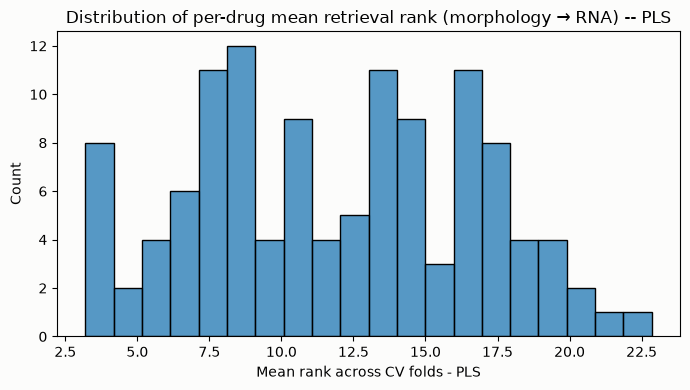

=== Best retrieved (lowest rank) ===
                   compound                       moa-fine  mean_rank      MRR  recall_at_1  recall_at_5
               Bendamustine DNA synthesis/repair inhibitor       3.20 0.422083         0.10         0.85
               Capivasertib             PI3K/AKT inhibitor       3.35 0.497202         0.30         0.80
                 Macitentan                        unclear       3.60 0.430795         0.20         0.90
                  Celecoxib       Cyclooxygenase inhibitor       3.65 0.376667         0.10         0.90
                Mebendazole          Microtubule inhibitor       3.70 0.629567         0.50         0.75
               Trimetrexate DNA synthesis/repair inhibitor       3.90 0.388056         0.15         0.80
                PF-06260933           Other MAPK inhibitor       3.95 0.434702         0.25         0.80
            Hexylresorcinol                        unclear       4.15 0.433393         0.20         0.85
                 N

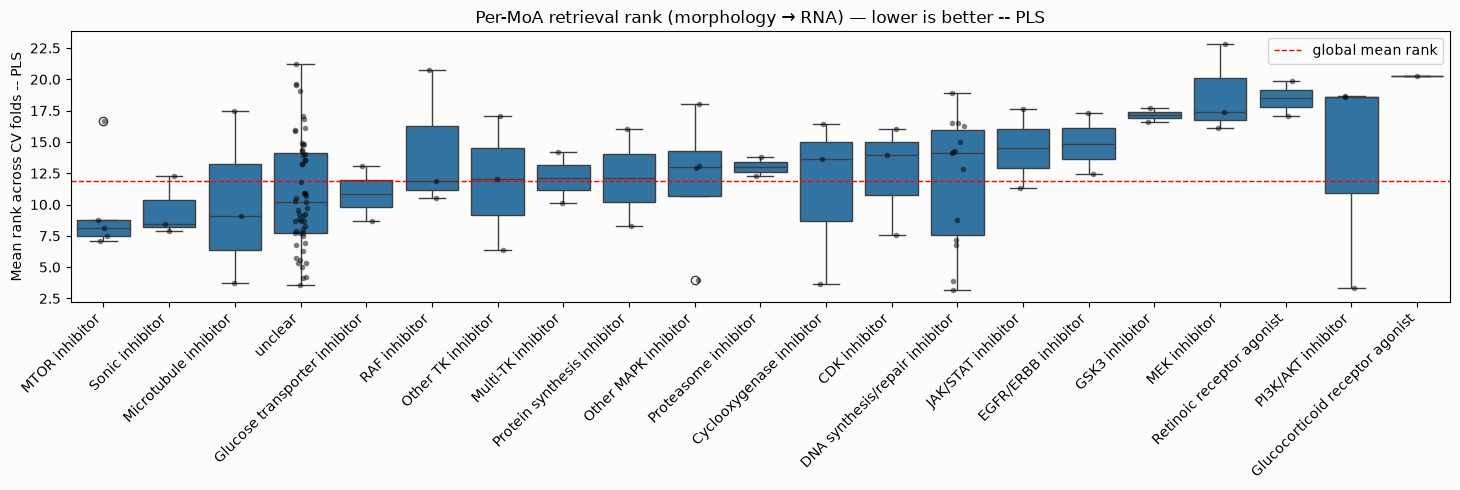

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

pls_agg_moa = pls_drug_agg.merge(moa_by_drug, left_on="compound",right_on="drug")

morph_to_rna = pls_agg_moa[
    (pls_agg_moa.direction == "morphology_to_rna") &
    (~pls_agg_moa.shuffled_train_pairs)  # exclude null control if present
]

# ── Plot 1: Rank distribution ────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 4))
sns.histplot(data=morph_to_rna, x="mean_rank", bins=20, ax=ax1)
ax1.set_title("Distribution of per-drug mean retrieval rank (morphology → RNA) -- PLS")
ax1.set_xlabel("Mean rank across CV folds - PLS")
fig1.tight_layout()
fig1.savefig("rank_distribution_PLS.png", dpi=150)
plt.show()

# ── Print best / worst compounds ─────────────────────────────────────────────
cols = ["compound", "moa-fine", "mean_rank", "MRR", "recall_at_1", "recall_at_5"]
print("=== Best retrieved (lowest rank) ===")
print(morph_to_rna.sort_values("mean_rank")[cols].head(10).to_string(index=False))
print("\n=== Worst retrieved (highest rank) ===")
print(morph_to_rna.sort_values("mean_rank")[cols].tail(10).to_string(index=False))

# ── Plot 2: MoA boxplot ───────────────────────────────────────────────────────
n_moa = morph_to_rna["moa-fine"].nunique()
fig2, ax2 = plt.subplots(figsize=(max(10, n_moa * 0.7), 5))

# Order MoAs by median rank so the plot is immediately readable
moa_order = (
    morph_to_rna.groupby("moa-fine")["mean_rank"]
    .median()
    .sort_values()
    .index
)

sns.boxplot(
    data=morph_to_rna,
    x="moa-fine", y="mean_rank",
    order=moa_order,
    ax=ax2,
)

sns.stripplot(
    data=morph_to_rna,
    x="moa-fine", y="mean_rank",
    order=moa_order,
    color="black", size=4, alpha=0.5, jitter=True,
    ax=ax2,
)

ax2.axhline(
    morph_to_rna["mean_rank"].mean(),
    color="red", linestyle="--", linewidth=1, label="global mean rank"
)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")
ax2.set_title("Per-MoA retrieval rank (morphology → RNA) — lower is better -- PLS")
ax2.set_ylabel("Mean rank across CV folds -- PLS")
ax2.set_xlabel("")
ax2.legend()
fig2.tight_layout()
fig2.savefig("moa_rank_boxplot_PLS.png", dpi=150)
plt.show()

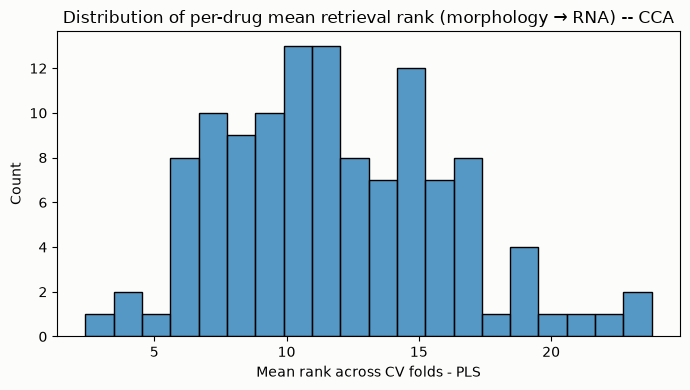

=== Best retrieved (lowest rank) ===
               compound                       moa-fine  mean_rank      MRR  recall_at_1  recall_at_5
               Bergenin                        unclear       2.40 0.615476         0.40         0.90
            palbociclib                  CDK inhibitor       3.95 0.467484         0.25         0.75
18β-Glycyrrhetinic acid                        unclear       4.05 0.415119         0.25         0.75
          Dapagliflozin  Glucose transporter inhibitor       5.30 0.465516         0.30         0.70
           Bendamustine DNA synthesis/repair inhibitor       5.65 0.321128         0.15         0.60
              Silodosin                        unclear       5.75 0.312859         0.10         0.45
             Pemetrexed DNA synthesis/repair inhibitor       5.80 0.311032         0.15         0.50
          Sulfisoxazole                        unclear       5.95 0.337377         0.15         0.55
           Capivasertib             PI3K/AKT inhibitor

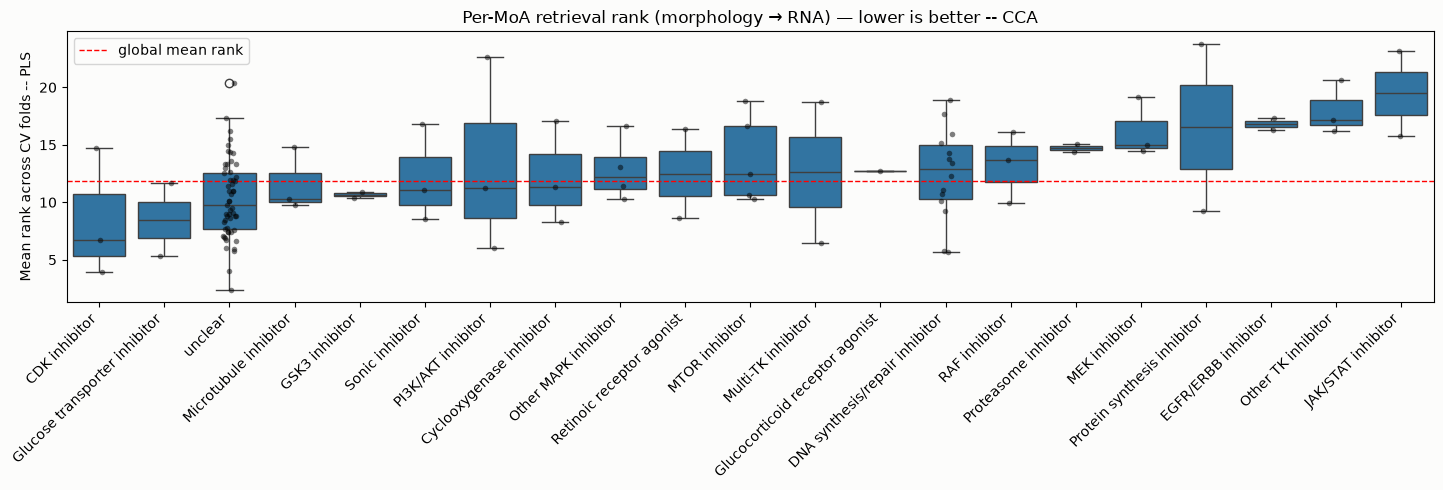

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

cca_agg_moa = cca_drug_agg.merge(moa_by_drug, left_on="compound",right_on="drug")

morph_to_rna = cca_agg_moa[
    (cca_agg_moa.direction == "morphology_to_rna") &
    (~cca_agg_moa.shuffled_train_pairs)  # exclude null control if present
]

# ── Plot 1: Rank distribution ────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 4))
sns.histplot(data=morph_to_rna, x="mean_rank", bins=20, ax=ax1)
ax1.set_title("Distribution of per-drug mean retrieval rank (morphology → RNA) -- CCA")
ax1.set_xlabel("Mean rank across CV folds - PLS")
fig1.tight_layout()
fig1.savefig("rank_distribution_CCA.png", dpi=150)
plt.show()

# ── Print best / worst compounds ─────────────────────────────────────────────
cols = ["compound", "moa-fine", "mean_rank", "MRR", "recall_at_1", "recall_at_5"]
print("=== Best retrieved (lowest rank) ===")
print(morph_to_rna.sort_values("mean_rank")[cols].head(10).to_string(index=False))
print("\n=== Worst retrieved (highest rank) ===")
print(morph_to_rna.sort_values("mean_rank")[cols].tail(10).to_string(index=False))

# ── Plot 2: MoA boxplot ───────────────────────────────────────────────────────
n_moa = morph_to_rna["moa-fine"].nunique()
fig2, ax2 = plt.subplots(figsize=(max(10, n_moa * 0.7), 5))

# Order MoAs by median rank so the plot is immediately readable
moa_order = (
    morph_to_rna.groupby("moa-fine")["mean_rank"]
    .median()
    .sort_values()
    .index
)

sns.boxplot(
    data=morph_to_rna,
    x="moa-fine", y="mean_rank",
    order=moa_order,
    ax=ax2,
)

sns.stripplot(
    data=morph_to_rna,
    x="moa-fine", y="mean_rank",
    order=moa_order,
    color="black", size=4, alpha=0.5, jitter=True,
    ax=ax2,
)

ax2.axhline(
    morph_to_rna["mean_rank"].mean(),
    color="red", linestyle="--", linewidth=1, label="global mean rank"
)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")
ax2.set_title("Per-MoA retrieval rank (morphology → RNA) — lower is better -- CCA")
ax2.set_ylabel("Mean rank across CV folds -- PLS")
ax2.set_xlabel("")
ax2.legend()
fig2.tight_layout()
fig2.savefig("moa_rank_boxplot_CCA.png", dpi=150)
plt.show()

In [46]:
drug_agg_moa

,compound,direction,shuffled_train_pairs,mean_rank,median_rank,MRR,recall_at_1,recall_at_5,n_folds_as_test,moa-fine
0,18β-Glycyrrhetinic acid,morphology_to_rna,False,7.70,8.0,0.225081,0.10,0.30,20,unclear
1,18β-Glycyrrhetinic acid,rna_to_morphology,False,8.65,8.5,0.147014,0.00,0.10,20,unclear
2,5-Fluorouracil,morphology_to_rna,False,15.00,15.0,0.072931,0.00,0.00,20,DNA synthesis/repair inhibitor
3,5-Fluorouracil,rna_to_morphology,False,6.20,6.0,0.222383,0.05,0.45,20,DNA synthesis/repair inhibitor
4,8-Hydroxyquinoline,morphology_to_rna,False,16.85,20.0,0.109595,0.05,0.05,20,unclear
...,...,...,...,...,...,...,...,...,...,...
233,olaparib,rna_to_morphology,False,21.10,21.0,0.047711,0.00,0.00,20,DNA synthesis/repair inhibitor
234,palbociclib,morphology_to_rna,False,13.95,15.0,0.077382,0.00,0.00,20,CDK inhibitor
235,palbociclib,rna_to_morphology,False,15.75,16.5,0.077513,0.00,0.05,20,CDK inhibitor
236,venetoclax,morphology_to_rna,False,14.25,14.0,0.082952,0.00,0.00,20,unclear


In [25]:
'''

pls_null = run_paired_retrieval_cv(
    X, Y,
    method="PLS",
    n_components=3,
    random_state=RANDOM_STATE,
    shuffle_train_pairs=True
)

cca_null = run_paired_retrieval_cv(
    X, Y,
    method="CCA",
    n_components=3,
    random_state=RANDOM_STATE,
    shuffle_train_pairs=True
)

null_results = pd.concat([pls_null, cca_null], ignore_index=True)

(
    null_results
    .groupby(["method", "direction"], observed=True)
    [["MRR", "Recall@1", "Recall@5", "median_rank"]]
    .agg(["mean", "std"])
    .round(3)
)

'''

MRR        Recall@1        Recall@5         \
                           mean    std     mean    std     mean    std   
method direction                                                         
CCA    morphology_to_rna  0.168  0.041    0.048  0.042    0.227  0.076   
       rna_to_morphology  0.166  0.042    0.050  0.039    0.224  0.093   
PLS    morphology_to_rna  0.153  0.035    0.035  0.036    0.204  0.066   
       rna_to_morphology  0.159  0.038    0.049  0.038    0.193  0.070   

                         median_rank         
                                mean    std  
method direction                             
CCA    morphology_to_rna      11.885  1.912  
       rna_to_morphology      12.060  2.037  
PLS    morphology_to_rna      12.395  1.741  
       rna_to_morphology      12.475  1.867

In [29]:
'''

N_NULL = 50

null_results = pd.concat(
    [
        run_paired_retrieval_cv(
            X, Y,
            method=method,
            n_components=3,
            random_state=RANDOM_STATE + null_id + 1,
            shuffle_train_pairs=True,
        ).assign(null_id=null_id)
        for null_id in range(N_NULL)
        for method in ["PLS", "CCA"]
    ],
    ignore_index=True,
)

(
    null_results
    .groupby(["method", "direction"], observed=True)
    [["MRR", "Recall@1", "Recall@5", "median_rank"]]
    .agg(["mean", "std"])
    .round(3)
)

'''

MRR        Recall@1        Recall@5         \
                           mean    std     mean    std     mean    std   
method direction                                                         
CCA    morphology_to_rna  0.167  0.038    0.047  0.041    0.225  0.074   
       rna_to_morphology  0.166  0.043    0.047  0.043    0.224  0.083   
PLS    morphology_to_rna  0.157  0.036    0.040  0.037    0.211  0.071   
       rna_to_morphology  0.160  0.042    0.043  0.040    0.215  0.084   

                         median_rank         
                                mean    std  
method direction                             
CCA    morphology_to_rna      11.910  1.766  
       rna_to_morphology      11.916  2.044  
PLS    morphology_to_rna      12.257  1.784  
       rna_to_morphology      12.212  2.034

For santiy check, test for NULL control (permuted) with PLS

In [49]:
N_NULL = 50

null_summary_list = []
null_drug_list = []

for null_id in range(N_NULL):
    for method in ["PLS", "CCA"]:
        summary_df, drug_df = run_paired_retrieval_cv(
            X, Y,
            compound_names=drug_names,
            method=method,
            n_components=3,
            random_state=RANDOM_STATE + null_id + 1,
            shuffle_train_pairs=True,
        )
        null_summary_list.append(summary_df.assign(null_id=null_id))
        null_drug_list.append(drug_df.assign(null_id=null_id))

null_results  = pd.concat(null_summary_list, ignore_index=True)
null_drug_agg_raw = pd.concat(null_drug_list,    ignore_index=True)

In [50]:
null_drug_agg = (
    null_drug_agg_raw
    .groupby(["compound", "direction"])   # collapse folds AND null_ids
    .agg(
        mean_rank       = ("rank",            "mean"),
        median_rank     = ("rank",            "median"),
        MRR             = ("reciprocal_rank", "mean"),
        recall_at_1     = ("recall_at_1",     "mean"),
        recall_at_5     = ("recall_at_5",     "mean"),
        n_observations  = ("rank",            "count"),  # folds × null_runs
    )
    .reset_index()
    .assign(shuffled_train_pairs=True)
)

=== REAL ===
                            MRR        Recall@1        Recall@5         \
                           mean    std     mean    std     mean    std   
method direction                                                         
CCA    morphology_to_rna  0.176  0.043    0.057  0.047    0.233  0.075   
       rna_to_morphology  0.189  0.044    0.062  0.045    0.266  0.085   
PLS    morphology_to_rna  0.162  0.037    0.042  0.042    0.225  0.070   
       rna_to_morphology  0.174  0.041    0.052  0.040    0.235  0.077   

                         median_rank         
                                mean    std  
method direction                             
CCA    morphology_to_rna      11.730  1.587  
       rna_to_morphology      11.105  2.104  
PLS    morphology_to_rna      11.610  1.908  
       rna_to_morphology      11.790  1.954  

=== NULL (mean ± std across 50 runs × folds) ===
                            MRR        Recall@1        Recall@5         \
                      

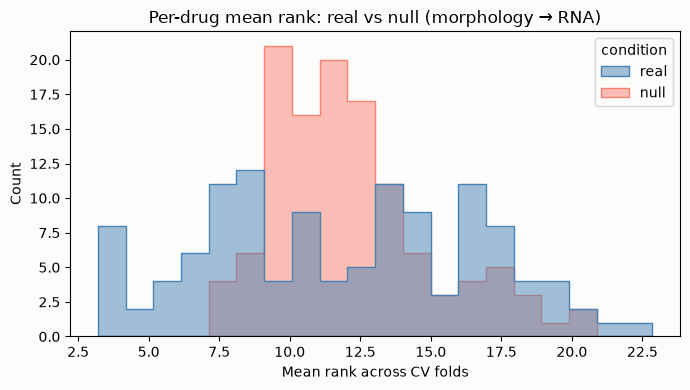

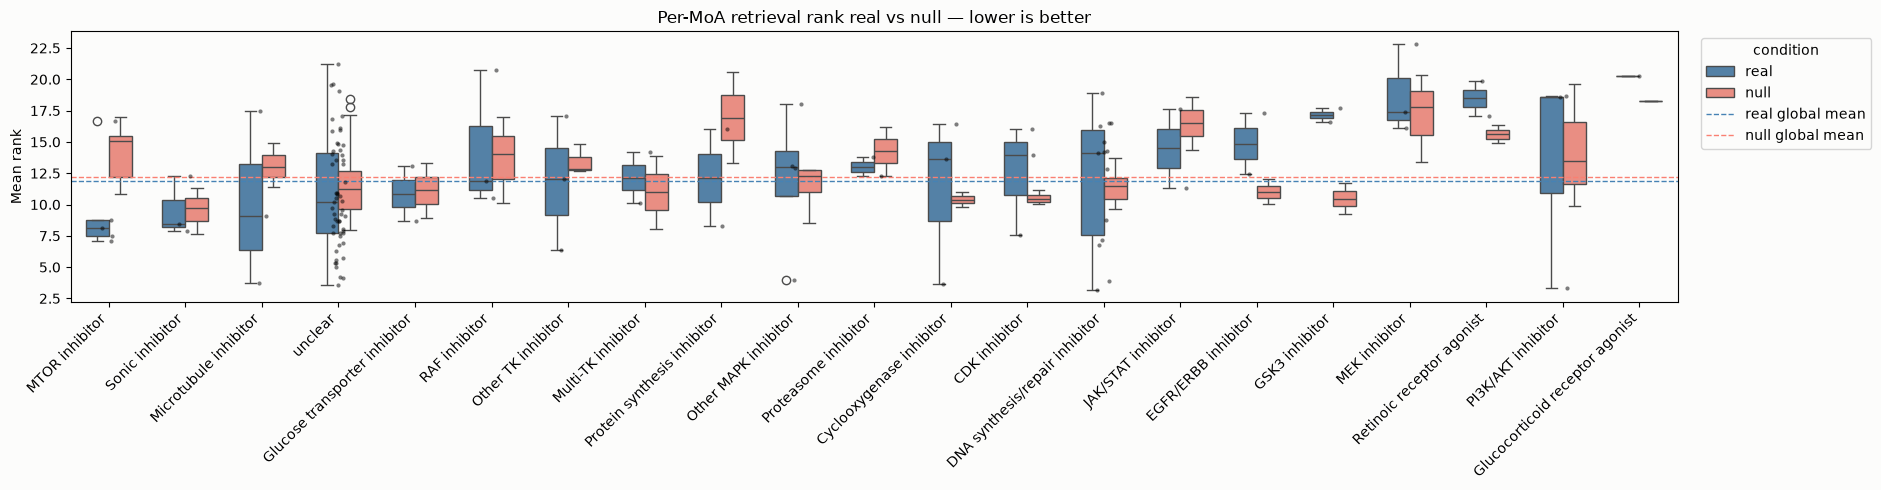

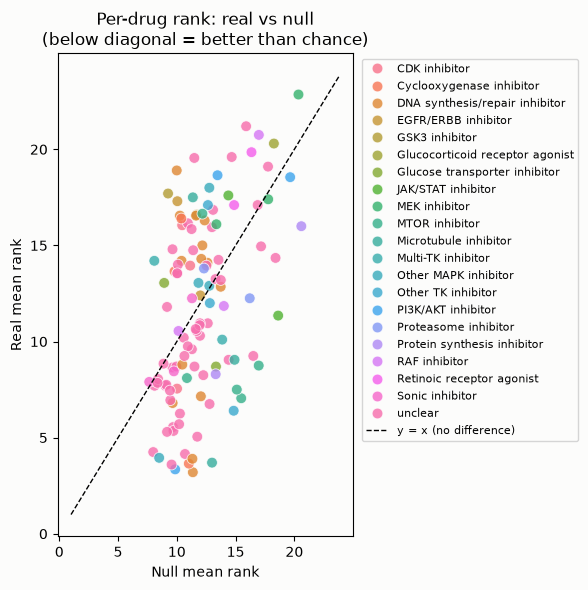

In [57]:
# ── Bulk summary table (your original groupby) ───────────────────────────────
print("=== REAL ===")
print(
    cv_results                          # your existing fold-level summary df
    .groupby(["method", "direction"])
    [["MRR", "Recall@1", "Recall@5", "median_rank"]]
    .agg(["mean", "std"])
    .round(3)
)
print("\n=== NULL (mean ± std across 50 runs × folds) ===")
print(
    null_results
    .groupby(["method", "direction"])
    [["MRR", "Recall@1", "Recall@5", "median_rank"]]
    .agg(["mean", "std"])
    .round(3)
)

# ── Combine real and null per-drug frames ────────────────────────────────────
# pls_drug_agg already has shuffled_train_pairs=False from the run
combined_drug = pd.concat(
    [
        pls_drug_agg.merge(moa_by_drug, left_on="compound", right_on="drug"),
        null_drug_agg.merge(moa_by_drug, left_on="compound", right_on="drug"),
    ],
    ignore_index=True,
).assign(
    condition=lambda df: df.shuffled_train_pairs.map(
        {False: "real", True: "null"}
    )
)

morph = combined_drug[combined_drug.direction == "morphology_to_rna"]

# ── Plot 1: Overlaid rank distributions real vs null ─────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 4))
sns.histplot(
    data=morph,
    x="mean_rank", hue="condition",
    bins=20, alpha=0.5, element="step",
    palette={"real": "steelblue", "null": "salmon"},
    ax=ax1,
)
ax1.set_title("Per-drug mean rank: real vs null (morphology → RNA)")
ax1.set_xlabel("Mean rank across CV folds")
fig1.tight_layout()
fig1.savefig("rank_distribution_vs_null.png", dpi=150)
plt.show()

# ── Plot 2: MoA boxplot real vs null side by side ────────────────────────────
moa_order = (
    morph[morph.condition == "real"]
    .groupby("moa-fine")["mean_rank"]
    .median()
    .sort_values()
    .index
)

n_moa = morph["moa-fine"].nunique()
fig2, ax2 = plt.subplots(figsize=(max(10, n_moa * 0.9), 5))

sns.boxplot(
    data=morph,
    x="moa-fine", y="mean_rank",
    hue="condition", order=moa_order,
    palette={"real": "steelblue", "null": "salmon"},
    width=0.6, ax=ax2,
)
sns.stripplot(
    data=morph[morph.condition == "real"],   # only annotate real drugs
    x="moa-fine", y="mean_rank",
    order=moa_order,
    color="black", size=3, alpha=0.5, jitter=True, dodge=True,
    ax=ax2,
)
ax2.axhline(
    morph[morph.condition == "real"]["mean_rank"].mean(),
    color="steelblue", linestyle="--", linewidth=1, label="real global mean"
)
ax2.axhline(
    morph[morph.condition == "null"]["mean_rank"].mean(),
    color="salmon", linestyle="--", linewidth=1, label="null global mean"
)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")
ax2.set_title("Per-MoA retrieval rank real vs null — lower is better")
ax2.set_ylabel("Mean rank")
ax2.set_xlabel("")
ax2.legend(title="condition", bbox_to_anchor=(1.01, 1), loc="upper left")
fig2.tight_layout()
fig2.savefig("moa_rank_boxplot_vs_null.png", dpi=150)
plt.show()

# ── Plot 3: Per-drug rank real vs null scatter (with MoA color) ──────────────
# Pivot so each compound is one row with real and null mean_rank columns
scatter_df = morph.pivot_table(
    index=["compound", "moa-fine"],
    columns="condition",
    values="mean_rank",
).reset_index()

fig3, ax3 = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    data=scatter_df,
    x="null", y="real",
    hue="moa-fine", alpha=0.8, s=60,
    ax=ax3,
)
lims = [1, scatter_df[["null", "real"]].max().max() + 1]
ax3.plot(lims, lims, "k--", linewidth=1, label="y = x (no difference)")
ax3.set_xlabel("Null mean rank")
ax3.set_ylabel("Real mean rank")
ax3.set_title("Per-drug rank: real vs null\n(below diagonal = better than chance)")
ax3.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
fig3.tight_layout()
fig3.savefig("per_drug_real_vs_null_scatter.png", dpi=150)
plt.show()

In [59]:
# ── Per-drug null statistics across all null runs × folds ────────────────────
null_drug_stats = (
    null_drug_agg_raw                          # raw records, one row per drug × fold × null_id
    .groupby(["compound", "direction"])
    .agg(
        null_mean_rank  = ("rank",            "mean"),
        null_std_rank   = ("rank",            "std"),
        null_mean_MRR   = ("reciprocal_rank", "mean"),
        null_std_MRR    = ("reciprocal_rank", "std"),
        n_null_obs      = ("rank",            "count"),
    )
    .reset_index()
)

# ── Per-drug empirical p-value (fraction of null runs where null rank <= real rank) ──
# Need per-null_id aggregated rank to compare against the single real value
null_per_run = (
    null_drug_agg_raw
    .groupby(["compound", "direction", "null_id"])
    .agg(run_mean_rank=("rank", "mean"))
    .reset_index()
)

def empirical_p(real_rank, null_ranks):
    """Fraction of null runs at least as good as real (one-sided, lower rank = better)."""
    return np.mean(null_ranks <= real_rank)

# Build empirical p per compound × direction
emp_p = (
    null_per_run
    .groupby(["compound", "direction"])
    .apply(
        lambda g: pd.Series({
            "null_run_mean_rank": g["run_mean_rank"].mean(),
            "null_run_std_rank":  g["run_mean_rank"].std(),
            # p = fraction of null runs that beat or match real rank
            # will be filled after merge below
            "_null_ranks_list":  g["run_mean_rank"].values,
        })
    )
    .reset_index()
)

# ── Merge real metrics with null stats ───────────────────────────────────────
enriched = (
    pls_drug_agg                              # your real per-drug aggregated table
    .merge(moa_by_drug, left_on="compound", right_on="drug")
    .merge(null_drug_stats, on=["compound", "direction"])
    .merge(emp_p,           on=["compound", "direction"])
)

# Now compute z-score and empirical p using the merged columns
enriched["rank_z_score"] = (
    (enriched["mean_rank"] - enriched["null_run_mean_rank"])
    / enriched["null_run_std_rank"].clip(lower=1e-6)   # avoid div/0
)

enriched["empirical_p"] = enriched.apply(
    lambda row: empirical_p(row["mean_rank"], row["_null_ranks_list"]),
    axis=1,
)

# Negative z = real rank is lower (better) than null mean
# p close to 0 = very few null runs beat the real result
enriched["better_than_null"] = enriched["rank_z_score"] < 0

enriched = enriched.drop(columns=["_null_ranks_list"])  # drop the list column

# ── Clean display ─────────────────────────────────────────────────────────────
display_cols = [
    "compound", "moa-fine", "direction",
    "mean_rank", "MRR",                          # real metrics
    "null_run_mean_rank", "null_run_std_rank",   # null baseline
    "rank_z_score", "empirical_p",               # comparison
    "better_than_null",
]

morph_enriched = (
    enriched[enriched.direction == "morphology_to_rna"][display_cols]
    .sort_values("rank_z_score")                 # most-improved-over-null first
    .reset_index(drop=True)
)

print(morph_enriched.sort_values(by='mean_rank').round(3).to_string())


                         compound                         moa-fine          direction  mean_rank    MRR  null_run_mean_rank  null_run_std_rank  rank_z_score  empirical_p  better_than_null
7                    Bendamustine   DNA synthesis/repair inhibitor  morphology_to_rna       3.20  0.422              11.362              1.083        -7.540         0.00              True
2                    Capivasertib               PI3K/AKT inhibitor  morphology_to_rna       3.35  0.497               9.860              0.796        -8.181         0.00              True
9                      Macitentan                          unclear  morphology_to_rna       3.60  0.431               9.552              0.819        -7.272         0.00              True
3                       Celecoxib         Cyclooxygenase inhibitor  morphology_to_rna       3.65  0.377              11.021              0.911        -8.094         0.00              True
1                     Mebendazole            Microtubule inh

Note : All of our prelim analyses that certain drugs may produce coordinated changes in RNA and morphology space, although they may not belong to the same MoA 

Note 2: All of our current analyses is done morphology_to_rna distance (row i is morphology profile, you search for closest RNA match .i.e finding matching cell state given shape. Morphology is the query space). This relationship is not symmetric; drug A closest morphology match to RNA-B doesn't imply that drug B is close to RNA A 

Possibly a metric of quality is drugs which are symmetric 



In [66]:
# Pivot
both_dirs = (
    pls_drug_agg
    .pivot_table(
        index="compound",
        columns="direction",
        values=["mean_rank", "median_rank", "MRR", "recall_at_1", "recall_at_5"]
    )
    .reset_index()
)

# Flatten columns
both_dirs.columns = [
    "compound"                if col == ("compound", "")                        else
    f"{col[0]}_m2r"           if col[1] == "morphology_to_rna"                  else
    f"{col[0]}_r2m"           if col[1] == "rna_to_morphology"                  else
    "_".join(col)             # fallback — should never hit
    for col in both_dirs.columns
]

print(both_dirs.columns.tolist())

# ── Merge MoA FIRST ───────────────────────────────────────────────────────────
both_dirs = both_dirs.merge(moa_by_drug, left_on="compound", right_on="drug")

# ── Then derived columns ──────────────────────────────────────────────────────
both_dirs["rank_diff"]      = both_dirs["mean_rank_r2m"] - both_dirs["mean_rank_m2r"]
both_dirs["rank_mean_both"] = (both_dirs["mean_rank_m2r"] + both_dirs["mean_rank_r2m"]) / 2
both_dirs["MRR_mean_both"]  = (both_dirs["MRR_m2r"]      + both_dirs["MRR_r2m"])       / 2

GOOD_RANK = 5
both_dirs["retrieval_class"] = np.select(
    [
        (both_dirs["mean_rank_m2r"] <= GOOD_RANK) & (both_dirs["mean_rank_r2m"] <= GOOD_RANK),
        (both_dirs["mean_rank_m2r"] <= GOOD_RANK) & (both_dirs["mean_rank_r2m"] >  GOOD_RANK),
        (both_dirs["mean_rank_m2r"] >  GOOD_RANK) & (both_dirs["mean_rank_r2m"] <= GOOD_RANK),
    ],
    ["both_good", "m2r_only", "r2m_only"],
    default="neither"
)

# ── Print ─────────────────────────────────────────────────────────────────────
print(
    both_dirs[["compound", "moa-fine", "mean_rank_m2r", "mean_rank_r2m",
               "rank_diff", "rank_mean_both", "retrieval_class"]]
    .sort_values("rank_mean_both")
    .to_string()
)
print("\nRetrieval class counts:")
print(both_dirs["retrieval_class"].value_counts())
print("\nRetrieval class by MoA:")
print(both_dirs.groupby("moa-fine")["retrieval_class"].value_counts().unstack(fill_value=0))

['compound', 'MRR_m2r', 'MRR_r2m', 'mean_rank_m2r', 'mean_rank_r2m', 'median_rank_m2r', 'median_rank_r2m', 'recall_at_1_m2r', 'recall_at_1_r2m', 'recall_at_5_m2r', 'recall_at_5_r2m']
                         compound                         moa-fine  mean_rank_m2r  mean_rank_r2m  rank_diff  rank_mean_both retrieval_class
14                   Bendamustine   DNA synthesis/repair inhibitor           3.20           2.65      -0.55           2.925       both_good
23                   Capivasertib               PI3K/AKT inhibitor           3.35           4.35       1.00           3.850       both_good
26                      Celecoxib         Cyclooxygenase inhibitor           3.65           4.15       0.50           3.900       both_good
4                        AZD-8055                   MTOR inhibitor           7.05           1.70      -5.35           4.375        r2m_only
13                    Belumosudil                          unclear           5.55           4.35      -1.20          

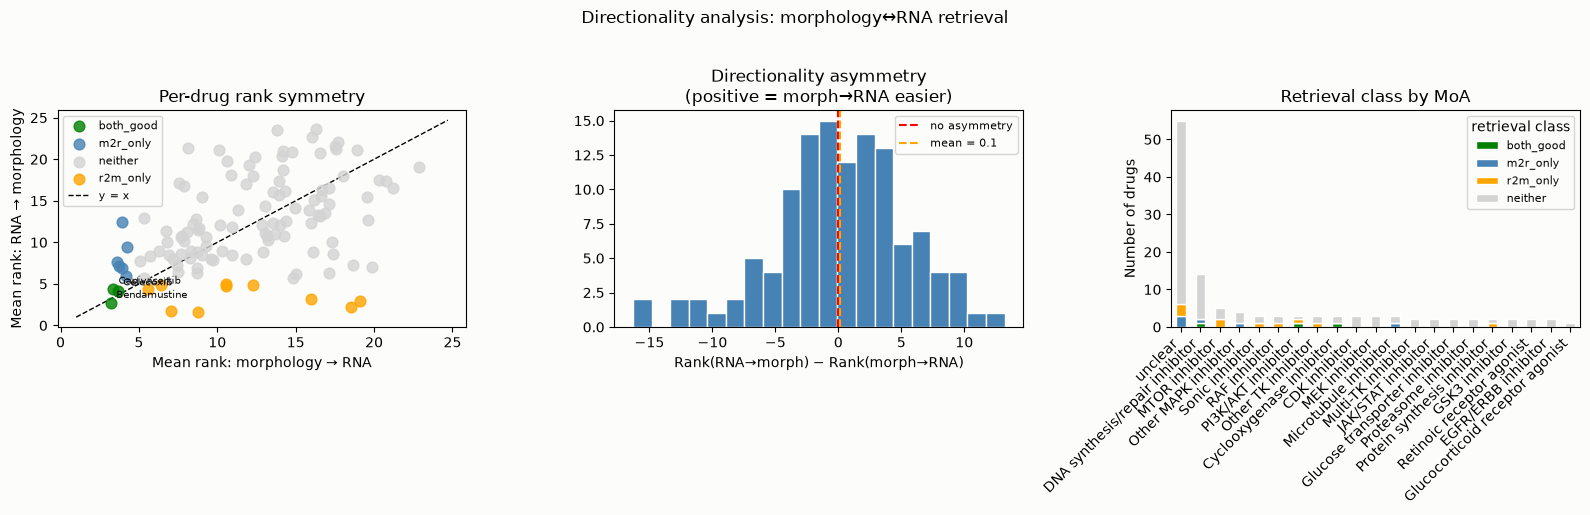

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Rank symmetry scatter ─────────────────────────────────────────────
palette = {"both_good": "green", "m2r_only": "steelblue",
           "r2m_only": "orange", "neither": "lightgrey"}

for cls, grp in both_dirs.groupby("retrieval_class"):
    axes[0].scatter(
        grp["mean_rank_m2r"], grp["mean_rank_r2m"],
        label=cls, color=palette[cls], alpha=0.8, s=60, zorder=3
    )

lim = [1, both_dirs[["mean_rank_m2r","mean_rank_r2m"]].max().max() + 1]
axes[0].plot(lim, lim, "k--", linewidth=1, label="y = x")
axes[0].set_xlabel("Mean rank: morphology → RNA")
axes[0].set_ylabel("Mean rank: RNA → morphology")
axes[0].set_title("Per-drug rank symmetry")
axes[0].legend(fontsize=8)

# Annotate the best drugs (both directions good)
for _, row in both_dirs[both_dirs.retrieval_class == "both_good"].iterrows():
    axes[0].annotate(
        row["compound"], (row["mean_rank_m2r"], row["mean_rank_r2m"]),
        fontsize=7, xytext=(4, 4), textcoords="offset points"
    )

# ── Plot 2: Rank difference distribution ─────────────────────────────────────
axes[1].hist(both_dirs["rank_diff"], bins=20, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="no asymmetry")
axes[1].axvline(both_dirs["rank_diff"].mean(), color="orange",
                linestyle="--", linewidth=1.5,
                label=f"mean = {both_dirs['rank_diff'].mean():.1f}")
axes[1].set_xlabel("Rank(RNA→morph) − Rank(morph→RNA)")
axes[1].set_title("Directionality asymmetry\n(positive = morph→RNA easier)")
axes[1].legend(fontsize=8)

# ── Plot 3: MoA breakdown of retrieval class ─────────────────────────────────
moa_counts = (
    both_dirs.groupby(["moa-fine", "retrieval_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["both_good","m2r_only","r2m_only","neither"])  
)
moa_counts = moa_counts.loc[moa_counts.sum(axis=1).sort_values(ascending=False).index]

moa_counts.plot(
    kind="bar", stacked=True, ax=axes[2],
    color=[palette[c] for c in moa_counts.columns],
    edgecolor="white"
)
axes[2].set_xlabel("")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha="right")
axes[2].set_title("Retrieval class by MoA")
axes[2].set_ylabel("Number of drugs")
axes[2].legend(title="retrieval class", fontsize=8)

plt.suptitle("Directionality analysis: morphology↔RNA retrieval", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("directionality_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

Generate embeddings based on the PLS and CCA coordinates -- This will be used to visualize UMAPs and compute silhouette scores 

There are possibly multiple ways to generate embeddings from these. You can simply concat the CCA/PLS vectors, average them or weight them based on canonical correlation weights 

In [75]:
moa_labels = moa_by_drug.loc[rna_compound_filt_pca.index].to_numpy()

print(moa_labels)
print(len(moa_labels))

pd.DataFrame({
    "drug":      rna_compound_filt_pca.index[:5],
    "moa_label": moa_labels[:5]
})

['unclear' 'DNA synthesis/repair inhibitor' 'unclear' 'CDK inhibitor'
 'MTOR inhibitor' 'GSK3 inhibitor' 'unclear' 'unclear' 'unclear'
 'PI3K/AKT inhibitor' 'DNA synthesis/repair inhibitor'
 'DNA synthesis/repair inhibitor' 'unclear' 'unclear'
 'DNA synthesis/repair inhibitor' 'unclear' 'Retinoic receptor agonist'
 'MEK inhibitor' 'Proteasome inhibitor' 'unclear' 'unclear'
 'Glucocorticoid receptor agonist' 'Glucose transporter inhibitor'
 'PI3K/AKT inhibitor' 'EGFR/ERBB inhibitor' 'unclear'
 'Cyclooxygenase inhibitor' 'unclear' 'unclear' 'unclear'
 'DNA synthesis/repair inhibitor' 'unclear' 'RAF inhibitor' 'unclear'
 'Glucose transporter inhibitor' 'unclear' 'unclear' 'unclear'
 'RAF inhibitor' 'Other TK inhibitor' 'unclear' 'unclear'
 'JAK/STAT inhibitor' 'unclear' 'unclear' 'Cyclooxygenase inhibitor'
 'unclear' 'Sonic inhibitor' 'unclear' 'Protein synthesis inhibitor'
 'DNA synthesis/repair inhibitor' 'DNA synthesis/repair inhibitor'
 'Other TK inhibitor' 'PI3K/AKT inhibitor'
 'DNA 

,drug,moa_label
0,18β-Glycyrrhetinic acid,unclear
1,5-Fluorouracil,DNA synthesis/repair inhibitor
2,8-Hydroxyquinoline,unclear
3,AT7519,CDK inhibitor
4,AZD-8055,MTOR inhibitor


In [76]:
def sign_align_and_scale(X_lat, Y_lat):
    """Align latent component signs and put both on a common scale."""
    signs = np.sign(np.sum(X_lat * Y_lat, axis=0))
    signs[signs == 0] = 1
    Y_lat = Y_lat * signs
    scaler = StandardScaler().fit(np.vstack([X_lat, Y_lat]))
    return scaler.transform(X_lat), scaler.transform(Y_lat)


def quality_weighted_embedding(X_lat, Y_lat, drug_names, both_dirs_df):
    """Weight each compound's latent coords by its per-drug MRR."""
    mrr_lookup = both_dirs_df.set_index("compound")[["MRR_m2r", "MRR_r2m"]]
    joint = np.zeros_like(X_lat)
    for i, drug in enumerate(drug_names):
        if drug not in mrr_lookup.index:
            joint[i] = (X_lat[i] + Y_lat[i]) / 2
            continue
        w_morph = mrr_lookup.loc[drug, "MRR_m2r"]
        w_rna   = mrr_lookup.loc[drug, "MRR_r2m"]
        total   = w_morph + w_rna
        joint[i] = (
            (X_lat[i] + Y_lat[i]) / 2 if total == 0
            else (w_morph * X_lat[i] + w_rna * Y_lat[i]) / total
        )
    return joint


def silhouette_valid(embedding, labels):
    """Silhouette score excluding singleton MoA classes."""
    labels = np.array(labels)
    counts = pd.Series(labels).map(pd.Series(labels).value_counts())
    valid  = counts.values > 1
    return silhouette_score(embedding[valid], labels[valid])


# ── Main comparison  ###

records = []

for method in ["PLS", "CCA"]:
    for n_comp in [2, 3, 5, 10]:

        # Scale inputs
        X_sc = StandardScaler().fit_transform(X)
        Y_sc = StandardScaler().fit_transform(Y)

        # Fit model
        model_class = PLSCanonical if method == "PLS" else CCA
        model = model_class(n_components=n_comp, scale=False, max_iter=1000, tol=1e-6)
        model.fit(X_sc, Y_sc)

        # Get latent coords
        X_lat, Y_lat = model.transform(X_sc, Y_sc)
        X_lat, Y_lat = sign_align_and_scale(X_lat, Y_lat)

        # Canonical correlation weights (one per component)
        canon_corrs = np.array([
            np.corrcoef(X_lat[:, k], Y_lat[:, k])[0, 1]
            for k in range(n_comp)
        ])
        weights = np.maximum(canon_corrs, 0)
        weights = weights / weights.sum() if weights.sum() > 0 else np.ones(n_comp) / n_comp

        # Build all embedding variants
        embeddings = {
            "morph_latent_only":    X_lat,
            "rna_latent_only":      Y_lat,
            "simple_average":       (X_lat + Y_lat) / 2,
            "concatenation":        np.hstack([X_lat, Y_lat]),
            "corrweighted_average": (X_lat * weights + Y_lat * weights) / 2,
            "quality_weighted":     quality_weighted_embedding(
                                        X_lat, Y_lat, drug_names, both_dirs
                                    ),
        }

        for emb_name, emb in embeddings.items():
            records.append({
                "method":     method,
                "n_comp":     n_comp,
                "embedding":  emb_name,
                "silhouette": silhouette_valid(emb, moa_labels),
            })

# Add raw PCA baselines once (independent of method/n_comp)
X_sc = StandardScaler().fit_transform(X)
Y_sc = StandardScaler().fit_transform(Y)
for name, emb in [("morph_pca_raw", X_sc), ("rna_pca_raw", Y_sc)]:
    records.append({
        "method": "baseline", "n_comp": None,
        "embedding": name,
        "silhouette": silhouette_valid(emb, moa_labels),
    })

results_df = pd.DataFrame(records)
print(results_df.sort_values("silhouette", ascending=False).to_string(index=False))



  method  n_comp            embedding  silhouette
     PLS    10.0        concatenation   -0.193445
     CCA    10.0        concatenation   -0.204381
     PLS    10.0      rna_latent_only   -0.215893
     CCA    10.0      rna_latent_only   -0.218529
     PLS    10.0 corrweighted_average   -0.222562
     PLS    10.0     quality_weighted   -0.225738
     PLS    10.0       simple_average   -0.226683
baseline     NaN          rna_pca_raw   -0.239441
     CCA    10.0     quality_weighted   -0.241187
     CCA    10.0 corrweighted_average   -0.241619
     CCA    10.0       simple_average   -0.245382
baseline     NaN        morph_pca_raw   -0.260461
     CCA    10.0    morph_latent_only   -0.278240
     CCA     5.0        concatenation   -0.281000
     PLS    10.0    morph_latent_only   -0.293124
     PLS     5.0        concatenation   -0.299157
     CCA     5.0      rna_latent_only   -0.307112
     CCA     5.0 corrweighted_average   -0.309286
     CCA     5.0       simple_average   -0.309662


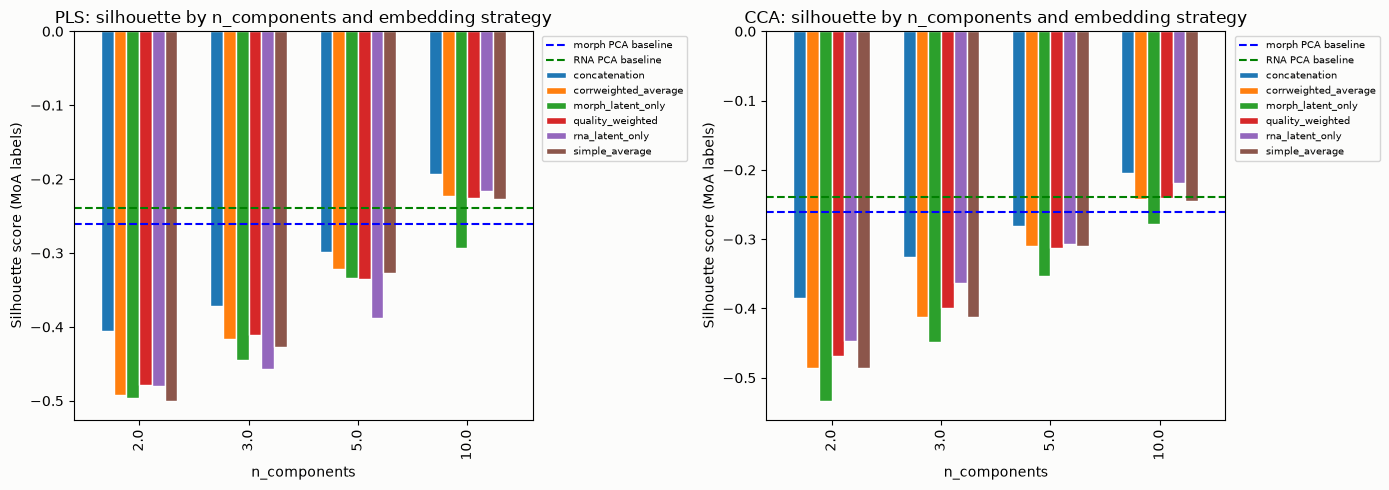

In [77]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, method in zip(axes, ["PLS", "CCA"]):
    subset = results_df[results_df.method == method]
    pivot  = subset.pivot(index="n_comp", columns="embedding", values="silhouette")
    pivot.plot(kind="bar", ax=ax, width=0.7, edgecolor="white")

    # Baseline reference lines
    baseline = results_df[results_df.method == "baseline"]
    ax.axhline(
        baseline.loc[baseline.embedding == "morph_pca_raw", "silhouette"].values[0],
        color="blue", linestyle="--", lw=1.5, label="morph PCA baseline"
    )
    ax.axhline(
        baseline.loc[baseline.embedding == "rna_pca_raw", "silhouette"].values[0],
        color="green", linestyle="--", lw=1.5, label="RNA PCA baseline"
    )
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(f"{method}: silhouette by n_components and embedding strategy")
    ax.set_xlabel("n_components")
    ax.set_ylabel("Silhouette score (MoA labels)")
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig("embedding_strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Higher components produce higher silhoutte sscores, although they are all still negative 

In [79]:
comp_sweep = pd.concat([
    run_paired_retrieval_cv(
        X, Y,
        compound_names=drug_names,
        method=method,
        n_components=n,
        random_state=RANDOM_STATE,
    )[0].assign(n_components=n, method=method)
    for method in ["PLS", "CCA"]
    for n in [2, 3, 5, 10]
], ignore_index=True)

print(
    comp_sweep
    .groupby(["method", "n_components", "direction"])
    [["MRR", "Recall@1", "Recall@5", "median_rank"]]
    .mean()
    .round(3)
)

                                         MRR  Recall@1  Recall@5  median_rank
method n_components direction                                                
CCA    2            morphology_to_rna  0.173     0.052     0.237       11.655
                    rna_to_morphology  0.181     0.058     0.261       11.245
       3            morphology_to_rna  0.176     0.057     0.233       11.730
                    rna_to_morphology  0.189     0.062     0.266       11.105
       5            morphology_to_rna  0.180     0.056     0.248       11.305
                    rna_to_morphology  0.195     0.069     0.270       10.755
       10           morphology_to_rna  0.176     0.049     0.254       11.080
                    rna_to_morphology  0.186     0.061     0.260       11.015
PLS    2            morphology_to_rna  0.166     0.045     0.231       11.405
                    rna_to_morphology  0.172     0.050     0.236       11.215
       3            morphology_to_rna  0.162     0.042     0.225